In [11]:
import numpy as np
from random import randint, seed
from math import ceil, log2, sqrt

seed(2025)

# Annexe : Générer une matrice de distance à partir de Qbits

## I. Paramètres du modèle

In [12]:
n = 4  # nombre de villes

max_coord = 20
max_weight_num = 1000
max_weight_den = 450

val_max = int(np.sqrt(2) * max_coord * (max_weight_num / max_weight_den))

## II. Génération aléatoire des points 

In [13]:
def gen_points(n):
    return [(randint(0, max_coord), randint(0, max_coord)) for _ in range(n)]

points = gen_points(n)
print("Points générés :", points)

Points générés : [(17, 2), (20, 15), (5, 16), (0, 11)]


## III. Construction de la matrice de distance

In [14]:
def create_weight_matrix(n, points):
    matrix = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            if i != j:
                p1 = points[i]
                p2 = points[j]

                weight = randint(max_weight_den, max_weight_num) / max_weight_den
                dist = sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

                matrix[i][j] = int(dist * weight)

    return matrix


distance_matrix = create_weight_matrix(n, points)

print("\n~~~~~ Matrice des distances : ~~~~~")
print(distance_matrix)
print(f"Valeurs entre 0 et {val_max}")


~~~~~ Matrice des distances : ~~~~~
[[ 0 24 28 22]
 [24  0 28 24]
 [20 19  0 10]
 [35 24 13  0]]
Valeurs entre 0 et 62


## IV. Encodage binaire de la matrice

In [ ]:
def encode_distance_matrix(distance_matrix, val_max):
    n = distance_matrix.shape[0]
    nb_bits = ceil(log2(val_max + 1))

    bits_matrix = np.zeros((n, n, nb_bits), dtype=bool)

    for i in range(n):
        for j in range(n):
            bits = bin(distance_matrix[i][j])[2:].zfill(nb_bits)
            bits_matrix[i][j] = [b == '1' for b in bits]

    return bits_matrix, nb_bits


bits_matrix, nb_bits = encode_distance_matrix(distance_matrix, val_max)

print(f"\nNombre de bits nécessaires : {nb_bits}")
print("\n~~~~~ Matrice binaire : ~~~~~")
for i in range(bits_matrix.shape[0]):
    ligne = ""
    for j in range(bits_matrix.shape[1]):
        bits = ""
        for b in bits_matrix[i, j]:
            bits += str(int(b))   # True/False -> 1/0

        # Ajouter le chiffre en binaire + séparateur
        ligne += bits
        if j < bits_matrix.shape[1] - 1:
            ligne += " | "
    
    print(ligne)


Nombre de bits nécessaires : 6

~~~~~ Matrice binaire : ~~~~~
000000 | 011000 | 011100 | 010110
011000 | 000000 | 011100 | 011000
010100 | 010011 | 000000 | 001010
100011 | 011000 | 001101 | 000000


## V. Préparation des registres quantiques

In [16]:
bitsV = ceil(log2(n)) # nb de bits pour encoder une ville (0..n-1)

q_addr_i = [f"qaddr_i[{i}]" for i in range(bitsV)]
q_addr_j = [f"qaddr_j[{i}]" for i in range(bitsV)]
q_dist   = [f"qval[{i}]" for i in range(nb_bits)]
anc      = [f"anc[{i}]" for i in range(2 * bitsV)]

print("\nRegistres :")
print("q_addr_i:", q_addr_i)
print("q_addr_j:", q_addr_j)
print("q_dist  :", q_dist)
print("anc     :", anc)


Registres :
q_addr_i: ['qaddr_i[0]', 'qaddr_i[1]']
q_addr_j: ['qaddr_j[0]', 'qaddr_j[1]']
q_dist  : ['qval[0]', 'qval[1]', 'qval[2]', 'qval[3]', 'qval[4]', 'qval[5]']
anc     : ['anc[0]', 'anc[1]', 'anc[2]', 'anc[3]']


## VI. Génération du QASM (oracle de matrice)

### VI.1. Portes quantiques simples

In [17]:
def addr_i(p): return f"qaddr_i[{p}]"
def addr_j(p): return f"qaddr_j[{p}]"
def val_k(k): return f"qval[{k}]"

def x(q): return f"x {q};"
def cx(a,b): return f"cx {a}, {b};"
def ccx(a,b,c): return f"ccx {a}, {b}, {c};"

### VI.2. Portes Multi-CX avec ancillas

In [18]:
def multi_cx(controls, target, anc):
    if len(controls) == 1:
        return [cx(controls[0], target)]
    if len(controls) == 2:
        return [ccx(controls[0], controls[1], target)]

    lines = []
    lines.append(ccx(controls[0], controls[1], anc[0]))

    for i in range(2, len(controls)-1):
        lines.append(ccx(controls[i], anc[i-2], anc[i-1]))

    lines.append(ccx(controls[-1], anc[len(controls)-3], target))

    # uncompute
    for i in reversed(range(2, len(controls)-1)):
        lines.append(ccx(controls[i], anc[i-2], anc[i-1]))

    lines.append(ccx(controls[0], controls[1], anc[0]))

    return lines

### VI.3. Matrice de distance 

In [19]:
def distance_matrix_quantique(distance_matrix, bitsV, q_dist, anc):
    lines = []
    lines.append('OPENQASM 2.0;')
    lines.append('include "qelib1.inc";')

    n = distance_matrix.shape[0]
    val_bits = len(q_dist)

    lines.append(f"qreg qaddr_i[{bitsV}];")
    lines.append(f"qreg qaddr_j[{bitsV}];")
    lines.append(f"qreg qval[{val_bits}];")
    lines.append(f"qreg anc[{len(anc)}];")

    for i in range(n):
        ibits = [(i >> b) & 1 for b in range(bitsV)]

        for j in range(n):
            jbits = [(j >> b) & 1 for b in range(bitsV)]
            val = int(distance_matrix[i, j])

            if val == 0:
                continue

            for b in range(bitsV):
                if ibits[b] == 0:
                    lines.append(x(addr_i(b)))
                if jbits[b] == 0:
                    lines.append(x(addr_j(b)))

            controls = [addr_i(b) for b in range(bitsV)] + \
                       [addr_j(b) for b in range(bitsV)]

            for k in range(val_bits):
                if ((val >> k) & 1) == 1:
                    lines.extend(multi_cx(controls, val_k(k), anc))

            for b in range(bitsV):
                if ibits[b] == 0:
                    lines.append(x(addr_i(b)))
                if jbits[b] == 0:
                    lines.append(x(addr_j(b)))

            lines.append("barrier;")

    return "\n".join(lines)

## VII. Génération de la matrice 

In [20]:
qasm = distance_matrix_quantique(distance_matrix, bitsV, q_dist, anc)
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg qaddr_i[2];
qreg qaddr_j[2];
qreg qval[6];
qreg anc[4];
x qaddr_i[0];
x qaddr_i[1];
x qaddr_j[1];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_j[1], anc[1], qval[3];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_j[1], anc[1], qval[4];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_i[0], qaddr_i[1], anc[0];
x qaddr_i[0];
x qaddr_i[1];
x qaddr_j[1];
barrier;
x qaddr_i[0];
x qaddr_j[0];
x qaddr_i[1];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_j[1], anc[1], qval[2];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_j[1], anc[1], qval[3];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_i[0], qaddr_i[1], anc[0];
ccx qaddr_j[0], anc[0], anc[1];
ccx qaddr_j[1], anc[1], 

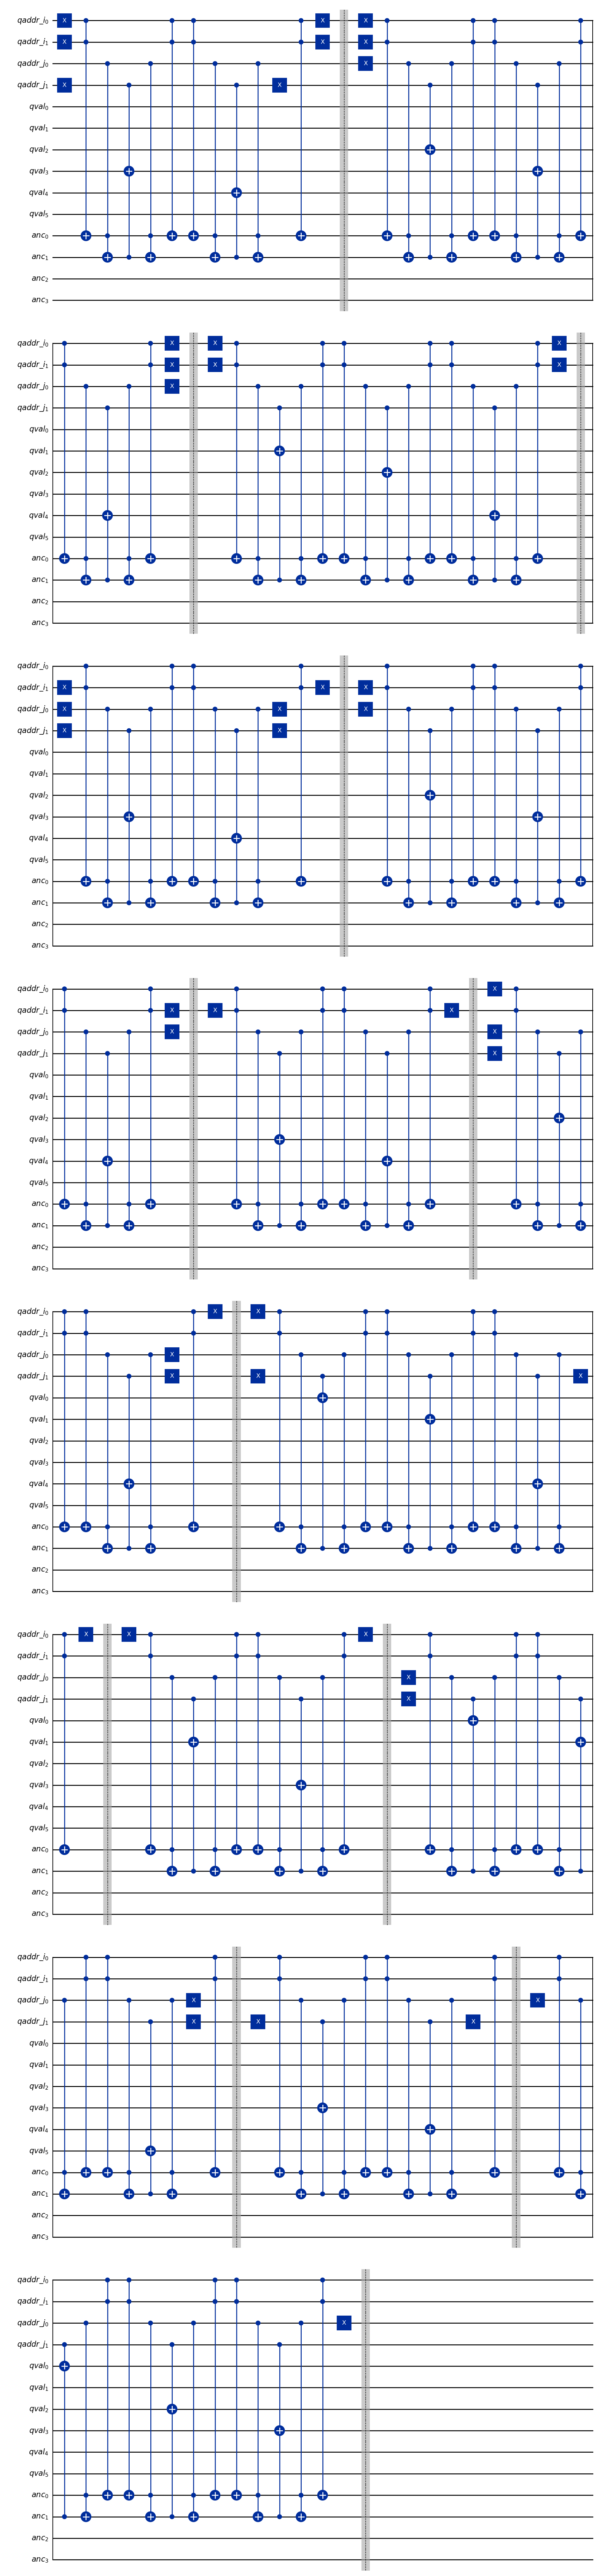

In [21]:
from qiskit import qasm2
circuit = qasm2.loads(qasm)
circuit.draw('mpl')